© 2025 Mobile Perception Systems Lab at TU/e. All rights reserved. Licensed under the MIT License.

## Setup

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
cd /content/drive/MyDrive/AnomalySegmentation_Project/eomt

/content/drive/.shortcut-targets-by-id/1x2LBwdmPjKFuYwX3GTOrlr8KeH9a9SXK/AnomalySegmentation_Project/eomt


In [4]:
!pip install -r requirements.txt

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 4.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 6.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 5.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 5.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.3/131.3 kB 15.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.6/8.6 MB 163.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 101.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 142.2 MB/

In [ ]:
import yaml
from lightning import seed_everything
import torch
from torch.nn import functional as F
from torch.amp.autocast_mode import autocast
import matplotlib.pyplot as plt
import numpy as np
import warnings
import importlib

seed_everything(0, verbose=False)

device = 0  # TODO: change to the GPU you want to use
img_idx = 246 # TODO: change to the index of the image you want to visualize
config_path_coco = "configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml"
config_path_cityscapes = "configs/dinov2/cityscapes/semantic/eomt_base_640.yaml"
data_path = "../Cityscapes"  # TODO: change to the dataset directory

with open(config_path_coco, "r") as f:
    config_coco = yaml.safe_load(f)

with open(config_path_cityscapes, "r") as f:
    config_city = yaml.safe_load(f)

def create_mapping(images, ignore_index):
    unique_ids = np.unique(np.concatenate([np.unique(img) for img in images]))
    valid_ids = unique_ids[unique_ids != ignore_index]
    colors = np.array(
        [plt.cm.hsv(i / len(valid_ids))[:3] for i in range(len(valid_ids))]
    )
    mapping = {cid: colors[i] for i, cid in enumerate(valid_ids)}
    mapping[ignore_index] = np.array([0, 0, 0])
    return mapping


def apply_colormap(image, mapping):
    colored_image = np.zeros((*image.shape, 3))
    for cid in np.unique(image):
        colored_image[image == cid] = mapping.get(cid, [0, 0, 0])
    return colored_image

## Load dataset

Ensure the dataset files are correctly prepared and placed in the folder specified by `data_path`.

In [ ]:
#CITYSCAPES
data_module_name_city, class_name_city = config_city["data"]["class_path"].rsplit(".", 1)
data_module_city = getattr(importlib.import_module(data_module_name_city), class_name_city)
data_kwargs_city = config_city["data"].get("init_args", {})

data_city = data_module_city(
    path=data_path,
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_city
)
data_city.setup()


#COCO
data_module_name_coco, class_name_coco = config_coco["data"]["class_path"].rsplit(".", 1)
data_module_coco = getattr(importlib.import_module(data_module_name_coco), class_name_coco)
data_kwargs_coco = config_coco["data"].get("init_args", {})

data_coco_meta = data_module_coco(
    path="",
    batch_size=1,
    num_workers=0,
    check_empty_targets=False,
    **data_kwargs_coco
)

## Load model

In [ ]:
warnings.filterwarnings(
    "ignore",
    message=r".*Attribute 'network' is an instance of `nn\.Module` and is already saved during checkpointing.*",
)

def build_and_load_model(config, data_meta, weights_path):
    # Load encoder
    encoder_cfg = config["model"]["init_args"]["network"]["init_args"]["encoder"]
    encoder_module_name, encoder_class_name = encoder_cfg["class_path"].rsplit(".", 1)
    encoder_cls = getattr(importlib.import_module(encoder_module_name), encoder_class_name)
    encoder = encoder_cls(img_size=data_meta.img_size, **encoder_cfg.get("init_args", {}))

    # Load network
    network_cfg = config["model"]["init_args"]["network"]
    network_module_name, network_class_name = network_cfg["class_path"].rsplit(".", 1)
    network_cls = getattr(importlib.import_module(network_module_name), network_class_name)
    network_kwargs = {k: v for k, v in network_cfg["init_args"].items() if k != "encoder"}

    network = network_cls(
        masked_attn_enabled=False,
        num_classes=data_meta.num_classes,
        encoder=encoder,
        **network_kwargs,
    )

    # Load Lightning module
    lit_module_name, lit_class_name = config["model"]["class_path"].rsplit(".", 1)
    lit_cls = getattr(importlib.import_module(lit_module_name), lit_class_name)
    model_kwargs = {k: v for k, v in config["model"]["init_args"].items() if k != "network"}

    if "stuff_classes" in config["data"].get("init_args", {}):
        model_kwargs["stuff_classes"] = config["data"]["init_args"]["stuff_classes"]

    name = config.get("trainer", {}).get("logger", {}).get("init_args", {}).get("name", "")
    is_dinov3 = "dinov3" in name

    if is_dinov3:
        model_kwargs["ckpt_path"] = weights_path
        model_kwargs["delta_weights"] = True

    model = (
        lit_cls(
            img_size=data_meta.img_size,
            num_classes=data_meta.num_classes,
            network=network,
            **model_kwargs,
        )
        .eval()
        .to(device)
    )

    if not is_dinov3:
        try:
            ckpt = torch.load(weights_path, map_location=device)
            if isinstance(ckpt, dict) and "state_dict" in ckpt:
                state_dict = ckpt["state_dict"]
            else:
                state_dict = ckpt
            model.load_state_dict(state_dict, strict=False)
            print(f"Weights successfully loaded from {weights_path}!")

        except Exception as e:
            print(f"Error loading weights from {weights_path}: {e}")

    return model

#COCO
state_dict_path_coco = "weights/eomt_coco.bin"
print("Initializing COCO Panoptic model...")
model_panoptic = build_and_load_model(config_coco, data_coco_meta, state_dict_path_coco)

#CITYSCAPES
state_dict_path_city = "weights/eomt_cityscapes.bin"
print("Initializing Cityscapes Semantic model...")
model_semantic = build_and_load_model(config_city, data_city, state_dict_path_city)

Initializing COCO Panoptic model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Weights successfully loaded from weights/eomt_coco.bin!
Initializing Cityscapes Semantic model...
Weights successfully loaded from weights/eomt_cityscapes.bin!


## Semantic inference (pixel-wise classification)

> This inference method also works when applied to a model trained for panoptic segmentation.

Semantic inference computes per-pixel class scores by combining mask and class predictions:

$$
\sum_i p_i(c) \cdot m_i[h, w]
$$

Here, $p_i(c)$ is the class probability for class $c$ (excluding "no object"), and $m_i[h, w]$ is the sigmoid-normalized mask value for query $i$ at pixel $(h, w)$. The final class is selected by taking the argmax over classes.  
  
*This inference method was originally introduced in MaskFormer.*

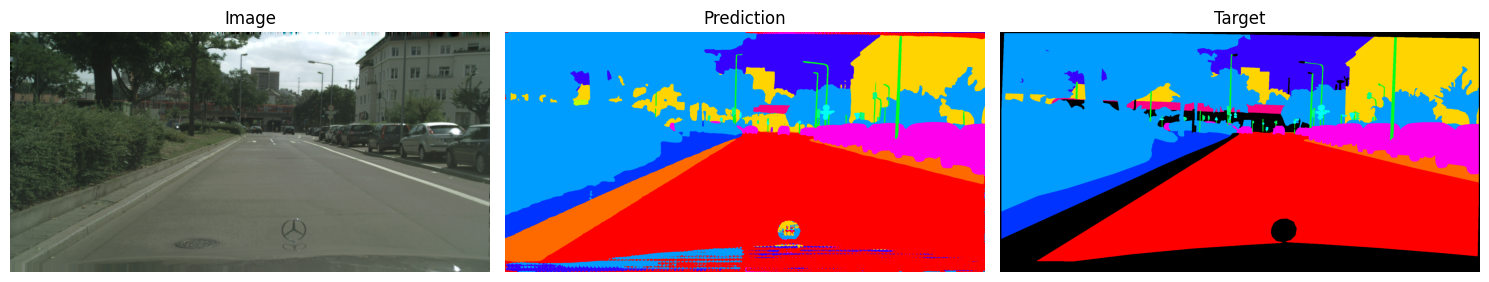

In [ ]:
IGNORE_INDEX = 255

def infer_semantic(model_sem, data_val, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        crops, origins = model_sem.window_imgs_semantic(imgs)

        mask_logits_per_layer, class_logits_per_layer = model_sem(crops)

        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], data_val.img_size, mode="bilinear"
        )

        crop_logits = model_sem.to_per_pixel_logits_semantic(
            mask_logits, class_logits_per_layer[-1]
        )
        logits = model_sem.revert_window_logits_semantic(crop_logits, origins, img_sizes)
        preds = logits[0].argmax(0).cpu()

    pred_array = preds.numpy()
    target_array = model_sem.to_per_pixel_targets_semantic([target], IGNORE_INDEX)[
        0
    ].numpy()
    return pred_array, target_array


def plot_semantic_results(img, pred_array, target_array):
    mapping = create_mapping([pred_array, target_array], IGNORE_INDEX)

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img.permute(1, 2, 0).cpu().numpy())
    axes[0].set_title("Image")
    axes[1].imshow(apply_colormap(pred_array, mapping))
    axes[1].set_title("Prediction")
    axes[2].imshow(apply_colormap(target_array, mapping))
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()

img, target = data_city.val_dataloader().dataset[img_idx]
pred_array, target_array = infer_semantic(model_semantic, data_city, img, target)
plot_semantic_results(img, pred_array, target_array)

## Panoptic inference (segmentation with instance IDs)

> This inference method also works when applied to a model trained for instance segmentation.

Panoptic inference assigns each pixel $[h, w]$ to the query $i$ that maximizes the product of class and mask confidence:

$$
p_i(c_i) \cdot m_i[h, w]
$$

where $c_i = \arg\max_c \, p_i(c)$ is the most likely class for query $i$. A pixel is assigned to a query only if both the class confidence and mask confidence are high. Pixels assigned to the same query form a segment labeled with $c_i$. "Stuff" segments with the same class are merged; "thing" segments are kept distinct using the query index. Low-confidence and heavily occluded predictions are filtered out.  
  
*This inference method was originally introduced in MaskFormer.*

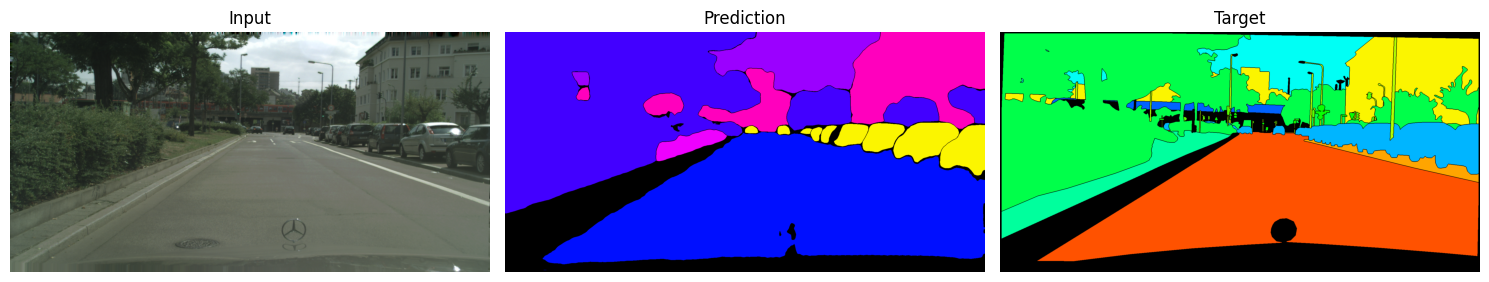

In [ ]:
def infer_panoptic(model_pan, img, target):
    with torch.no_grad(), autocast(dtype=torch.float16, device_type="cuda"):
        imgs = [img.to(device)]
        img_sizes = [img.shape[-2:] for img in imgs]

        transformed_imgs = model_pan.resize_and_pad_imgs_instance_panoptic(imgs)
        mask_logits_per_layer, class_logits_per_layer = model_pan(transformed_imgs)
        mask_logits = F.interpolate(
            mask_logits_per_layer[-1], model_pan.img_size, mode="bilinear"
        )
        mask_logits = model_pan.revert_resize_and_pad_logits_instance_panoptic(
            mask_logits, img_sizes
        )

        preds = model_pan.to_per_pixel_preds_panoptic(
            mask_logits,
            class_logits_per_layer[-1],
            model_pan.stuff_classes,
            model_pan.mask_thresh,
            model_pan.overlap_thresh,
        )[0].cpu()

    pred = preds.numpy()
    sem_pred, inst_pred = pred[..., 0], pred[..., 1]

    target_seg = model_pan.to_per_pixel_targets_panoptic([target])[0].cpu().numpy()
    sem_target, inst_target = target_seg[..., 0], target_seg[..., 1]

    return sem_pred, inst_pred, sem_target, inst_target


def draw_black_border(sem, inst, mapping):
    h, w = sem.shape
    out = np.zeros((h, w, 3))
    for s in np.unique(sem):
        out[sem == s] = mapping[s]

    combined = sem.astype(np.int64) * 100000 + inst.astype(np.int64)
    border = np.zeros((h, w), dtype=bool)
    border[1:, :] |= combined[1:, :] != combined[:-1, :]
    border[:-1, :] |= combined[1:, :] != combined[:-1, :]
    border[:, 1:] |= combined[:, 1:] != combined[:, :-1]
    border[:, :-1] |= combined[:, 1:] != combined[:, :-1]
    out[border] = 0
    return out


def plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, num_classes):
    all_ids = np.union1d(np.unique(sem_pred), np.unique(sem_target))
    mapping = {
        s: (
            [0, 0, 0]
            if s == -1 or s == num_classes
            else plt.cm.hsv(i / len(all_ids))[:3]
        )
        for i, s in enumerate(all_ids)
    }

    vis_pred = draw_black_border(sem_pred, inst_pred, mapping)
    vis_target = draw_black_border(sem_target, inst_target, mapping)

    img_np = (
        img.cpu().numpy().transpose(1, 2, 0) if img.dim() == 3 else img.cpu().numpy()
    )

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].imshow(img_np)
    axes[0].set_title("Input")
    axes[1].imshow(vis_pred)
    axes[1].set_title("Prediction")
    axes[2].imshow(vis_target)
    axes[2].set_title("Target")

    for ax in axes:
        ax.axis("off")

    plt.tight_layout()
    plt.show()


img, target = data_city.val_dataloader().dataset[img_idx]
sem_pred, inst_pred, sem_target, inst_target = infer_panoptic(model_panoptic, img, target)
plot_panoptic_results(img, sem_pred, inst_pred, sem_target, inst_target, model_panoptic.num_classes)

**Exercise 7**

In [ ]:
cd /content/drive/MyDrive/AnomalySegmentation_Project/eval

/content/drive/.shortcut-targets-by-id/1x2LBwdmPjKFuYwX3GTOrlr8KeH9a9SXK/AnomalySegmentation_Project/eval


In [ ]:
# 1. Create the directory safely
!mkdir -p /content/Cityscapes

# 2. Extract the ground truth labels
!echo "Extracting gtFine..."
!unzip -q /content/drive/MyDrive/AnomalySegmentation_Project/Cityscapes/gtFine_trainvaltest.zip -d /content/Cityscapes

# 3. Extract the images
!echo "Extracting leftImg8bit..."
!unzip -q /content/drive/MyDrive/AnomalySegmentation_Project/Cityscapes/leftImg8bit_trainvaltest.zip -d /content/Cityscapes

!echo "Done!"

Extracting gtFine...
Extracting leftImg8bit...
replace /content/Cityscapes/README? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace /content/Cityscapes/license.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
n
A
Done!


In [ ]:
!python eval_iou.py --loadWeights erfnet_pretrained.pth --datadir /content/Cityscapes/

In [ ]:
!python evalAnomaly.py --model_type erfnet --weights ../trained_models/erfnet_pretrained.pth --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly21/images/*.png"

!python evalAnomaly.py --model_type erfnet --weights ../trained_models/erfnet_pretrained.pth --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadObsticle21/images/*.webp"

!python evalAnomaly.py --model_type erfnet --weights ../trained_models/erfnet_pretrained.pth --input "../Anomaly_Validation_Datasets/Validation_Dataset/FS_LostFound_full/images/*.png"

!python evalAnomaly.py --model_type erfnet --weights ../trained_models/erfnet_pretrained.pth --input "../Anomaly_Validation_Datasets/Validation_Dataset/fs_static/images/*.jpg"

!python evalAnomaly.py --model_type erfnet --weights ../trained_models/erfnet_pretrained.pth --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg"




Initializing ERFNET model...

Starting evaluation loop...
--- ERFNET EVALUATION RESULTS on RoadAnomaly21 (Temperature: 1.0) ---
MSP          -> AUPRC: 29.09 | FPR@TPR95: 62.56
MaxLogit     -> AUPRC: 38.30 | FPR@TPR95: 59.36
MaxEntropy   -> AUPRC: 30.96 | FPR@TPR95: 62.68

Initializing ERFNET model...

Starting evaluation loop...
--- ERFNET EVALUATION RESULTS on RoadObsticle21 (Temperature: 1.0) ---
MSP          -> AUPRC: 2.71 | FPR@TPR95: 65.25
MaxLogit     -> AUPRC: 4.63 | FPR@TPR95: 48.48
MaxEntropy   -> AUPRC: 3.04 | FPR@TPR95: 65.93

Initializing ERFNET model...

Starting evaluation loop...
--- ERFNET EVALUATION RESULTS on FS_LostFound_full (Temperature: 1.0) ---
MSP          -> AUPRC: 1.75 | FPR@TPR95: 50.63
MaxLogit     -> AUPRC: 3.30 | FPR@TPR95: 45.53
MaxEntropy   -> AUPRC: 2.58 | FPR@TPR95: 50.19

Initializing ERFNET model...

Starting evaluation loop...
--- ERFNET EVALUATION RESULTS on fs_static (Temperature: 1.0) ---
MSP          -> AUPRC: 7.47 | FPR@TPR95: 41.83
MaxLogit  

**Exercise 8**

COCO

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml --weights ../eomt/weights/eomt_coco.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly21/images/*.png"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml --weights ../eomt/weights/eomt_coco.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadObsticle21/images/*.webp"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml --weights ../eomt/weights/eomt_coco.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/FS_LostFound_full/images/*.png"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml --weights ../eomt/weights/eomt_coco.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/fs_static/images/*.jpg"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/coco/panoptic/eomt_base_640_2x.yaml --weights ../eomt/weights/eomt_coco.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg"



Initializing EOMT model...
2026-05-17 19:16:17.769346: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 19:16:17.839463: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...
--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temper

CItyscapes

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml --weights ../eomt/weights/eomt_cityscapes.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly21/images/*.png"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml --weights ../eomt/weights/eomt_cityscapes.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadObsticle21/images/*.webp"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml --weights ../eomt/weights/eomt_cityscapes.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/FS_LostFound_full/images/*.png"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml --weights ../eomt/weights/eomt_cityscapes.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/fs_static/images/*.jpg"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_base_640.yaml --weights ../eomt/weights/eomt_cityscapes.bin --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg"


Initializing EOMT model...
2026-05-17 19:20:09.335835: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-17 19:20:09.404984: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...
--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temper

Coco Finetuned

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly21/images/*.png"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadObsticle21/images/*.webp"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/FS_LostFound_full/images/*.png"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/fs_static/images/*.jpg"

!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg"


Initializing EOMT model...
model.safetensors: 100% 346M/346M [00:04<00:00, 84.6MB/s]
2026-05-19 14:48:40.564115: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 14:48:40.635723: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation lo

Temperature scaling

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml \
--weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly21/images/*.png" \
--temperature 1.0 0.5 0.75 1.1 1.2



Initializing EOMT model...
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 1.0) ---
MSP          -> AUPRC: 55.81 | FPR@TPR95: 30.60
MaxLogit     -> AUPRC: 55.37 | FPR@TPR95: 30.57
MaxEntropy   -> AUPRC: 54.30 | FPR@TPR95: 28.63
RbA          -> AUPRC: 40.00 | FPR@TPR95: 94.52

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.5) ---
MSP          -> AUPRC: 53.15 | FPR@TPR95: 47.71
MaxLogit     -> AUPRC: 55.37 | FPR@TPR95: 30.57
MaxEntropy   -> AUPRC: 54.30 | FPR@TPR95: 28.63
RbA          -> AUPRC: 40.00 | FPR@TPR95: 94.52

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.75) ---
MSP          -> AUPRC: 54.87 | FPR@TPR95: 35.82
MaxLogit     -> AUPRC: 55.37 | FPR@TPR

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadObsticle21/images/*.webp" --temperature 0.5 0.75 1.1


Initializing EOMT model...
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...

--- EOMT EVALUATION RESULTS on RoadObsticle21 (Temperature: 0.5) ---
MSP          -> AUPRC: 77.12 | FPR@TPR95: 3.10
MaxLogit     -> AUPRC: 68.15 | FPR@TPR95: 3.24
MaxEntropy   -> AUPRC: 65.82 | FPR@TPR95: 3.72
RbA          -> AUPRC: 56.11 | FPR@TPR95: 97.93

--- EOMT EVALUATION RESULTS on RoadObsticle21 (Temperature: 0.75) ---
MSP          -> AUPRC: 73.80 | FPR@TPR95: 2.99
MaxLogit     -> AUPRC: 68.15 | FPR@TPR95: 3.24
MaxEntropy   -> AUPRC: 65.82 | FPR@TPR95: 3.72
RbA          -> AUPRC: 56.11 | FPR@TPR95: 97.93

--- EOMT EVALUATION RESULTS on RoadObsticle21 (Temperature: 1.1) ---
MSP          -> AUPRC: 65.21 | FPR@TPR95: 2.95
MaxLogit     -> AUPRC: 68.15 | FPR@TPR95: 

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/FS_LostFound_full/images/*.png" --temperature 0.5 0.75 1.1


Initializing EOMT model...
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...

--- EOMT EVALUATION RESULTS on FS_LostFound_full (Temperature: 0.5) ---
MSP          -> AUPRC: 35.09 | FPR@TPR95: 21.15
MaxLogit     -> AUPRC: 32.63 | FPR@TPR95: 20.40
MaxEntropy   -> AUPRC: 32.25 | FPR@TPR95: 20.24
RbA          -> AUPRC: 31.49 | FPR@TPR95: 92.48

--- EOMT EVALUATION RESULTS on FS_LostFound_full (Temperature: 0.75) ---
MSP          -> AUPRC: 33.55 | FPR@TPR95: 20.86
MaxLogit     -> AUPRC: 32.63 | FPR@TPR95: 20.40
MaxEntropy   -> AUPRC: 32.25 | FPR@TPR95: 20.24
RbA          -> AUPRC: 31.49 | FPR@TPR95: 92.48

--- EOMT EVALUATION RESULTS on FS_LostFound_full (Temperature: 1.1) ---
MSP          -> AUPRC: 31.55 | FPR@TPR95: 19.84
MaxLogit     -> AUPRC: 32.

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/fs_static/images/*.jpg" --temperature 0.5 0.75 1.1


Initializing EOMT model...
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...

--- EOMT EVALUATION RESULTS on fs_static (Temperature: 0.5) ---
MSP          -> AUPRC: 78.92 | FPR@TPR95: 10.48
MaxLogit     -> AUPRC: 81.41 | FPR@TPR95: 9.14
MaxEntropy   -> AUPRC: 81.32 | FPR@TPR95: 9.21
RbA          -> AUPRC: 84.09 | FPR@TPR95: 3.89

--- EOMT EVALUATION RESULTS on fs_static (Temperature: 0.75) ---
MSP          -> AUPRC: 79.89 | FPR@TPR95: 10.35
MaxLogit     -> AUPRC: 81.41 | FPR@TPR95: 9.14
MaxEntropy   -> AUPRC: 81.32 | FPR@TPR95: 9.21
RbA          -> AUPRC: 84.09 | FPR@TPR95: 3.89

--- EOMT EVALUATION RESULTS on fs_static (Temperature: 1.1) ---
MSP          -> AUPRC: 81.01 | FPR@TPR95: 9.91
MaxLogit     -> AUPRC: 81.41 | FPR@TPR95: 9.14
MaxEntropy

In [ ]:
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg" --temperature 0.5 0.75 1.1


Initializing EOMT model...
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...

--- EOMT EVALUATION RESULTS on RoadAnomaly (Temperature: 0.5) ---
MSP          -> AUPRC: 75.33 | FPR@TPR95: 24.66
MaxLogit     -> AUPRC: 69.06 | FPR@TPR95: 22.07
MaxEntropy   -> AUPRC: 70.11 | FPR@TPR95: 20.81
RbA          -> AUPRC: 67.23 | FPR@TPR95: 22.34

--- EOMT EVALUATION RESULTS on RoadAnomaly (Temperature: 0.75) ---
MSP          -> AUPRC: 72.44 | FPR@TPR95: 24.41
MaxLogit     -> AUPRC: 69.06 | FPR@TPR95: 22.07
MaxEntropy   -> AUPRC: 70.11 | FPR@TPR95: 20.81
RbA          -> AUPRC: 67.23 | FPR@TPR95: 22.34

--- EOMT EVALUATION RESULTS on RoadAnomaly (Temperature: 1.1) ---
MSP          -> AUPRC: 68.05 | FPR@TPR95: 21.26
MaxLogit     -> AUPRC: 69.06 | FPR@TPR95: 22

In [ ]:
# 1. SMIYC RoadAnomaly21
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly21/images/*.png" --temperature 0.4 0.45 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.15 1.20 1.25

# 2. SMIYC RoadObsticle21
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadObsticle21/images/*.webp" --temperature 0.4 0.45 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.15 1.20 1.25

# 3. Fishyscapes LostAndFound
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/FS_LostFound_full/images/*.png" --temperature 0.4 0.45 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.15 1.20 1.25

# 4. Fishyscapes Static
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/fs_static/images/*.jpg" --temperature 0.4 0.45 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.15 1.20 1.25

# 5. Road Anomaly (Original)
!python evalAnomaly.py --model_type eomt --config ../eomt/configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml --weights ../eomt/eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt --input "../Anomaly_Validation_Datasets/Validation_Dataset/RoadAnomaly/images/*.jpg" --temperature 0.4 0.45 0.5 0.55 0.6 0.65 0.7 0.75 0.8 0.85 0.9 0.95 1.15 1.20 1.25


Initializing EOMT model...
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/parsing.py:213: Attribute 'network' is an instance of `nn.Module` and is already saved during checkpointing. It is recommended to ignore them using `self.save_hyperparameters(ignore=['network'])`.

Starting evaluation loop...

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.4) ---
MSP          -> AUPRC: 51.87 | FPR@TPR95: 58.75

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.45) ---
MSP          -> AUPRC: 52.77 | FPR@TPR95: 52.22

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.5) ---
MSP          -> AUPRC: 53.15 | FPR@TPR95: 47.71

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.55) ---
MSP          -> AUPRC: 53.14 | FPR@TPR95: 44.23

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.6) ---
MSP          -> AUPRC: 54.20 | FPR@TPR95: 41.39

--- EOMT EVALUATION RESULTS on RoadAnomaly21 (Temperature: 0.65) ---
MSP          -> AUPRC

In [8]:
!python eval_mIou.py \
  --config configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml \
  --weights eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt \
  --data_path ../Cityscapes \
  --eval_type mapped_17

Initializing model...
2026-05-19 18:31:32.704368: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 18:31:32.775451: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Weights successfully loaded from eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt!
Starting evaluation (eval_type=mapped_17, mapping_active=False)...
Processing: 100% 500/500 [01:55<00:00,  4.34it/s]

CLASS                | IoU (%)               
-------------------------------------------------------
road                 |              97

In [9]:
!python eval_mIou.py \
  --config configs/dinov2/cityscapes/semantic/eomt_finetune_base_640.yaml \
  --weights eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt \
  --data_path ../Cityscapes \
  --eval_type all_19

Initializing model...
2026-05-19 18:33:55.970989: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-19 18:33:56.041676: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
Weights successfully loaded from eomt/finetune_unfreeze3_batch16_final/checkpoints/best.ckpt!
Starting evaluation (eval_type=all_19, mapping_active=False)...
Processing: 100% 500/500 [01:54<00:00,  4.36it/s]

CLASS                | IoU (%)               
-------------------------------------------------------
road                 |              97.96